# Task f - Part 2

Consider the single country model from c. Investigate how sensitive the optimal capacity mix is tothe global CO2 constraint. E.g., plot the generation mix as a function of the CO2 constraint that you impose. Search for the CO2 emissions in your country (today or in 1990) and refer to the emissions allowance for that historical data.

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0). 

This database compiles assumptions and projections for a wide range of energy system technologies for different years. The data can be imported into Python and loaded into a pandas.DataFrame. 

In [99]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [100]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0, # add CO2 intensity
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"] # cost of CCGT with CO2 emissions
costs.at["coal", "CO2 intensity"] = costs.at["coal", "CO2 intensity"] # cost of coal with CO2 emissions

In [101]:
#calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

#calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

#calculate capital cost
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

technologies = ["onwind", "solar", "CCGT", "coal", "PHS"]

# add CO2 intensity for coal and CCGT and efficiency
data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
    "Efficiency": [costs.at[t, "efficiency"] for t in technologies],
    "CO2 intensity (tCO2/MWh_th)": [costs.at[t, "CO2 intensity"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)

cost_table

,Capital cost (EUR/MW/a),Marginal cost (EUR/MWh),Efficiency,CO2 intensity (tCO2/MWh_th)
onwind,101644.123324,1.428600,1.000,0.0000
solar,51346.829820,0.010600,1.000,0.0000
CCGT,104788.020783,46.803121,0.580,0.1980
coal,337208.027448,30.098840,0.356,0.3361
PHS,182698.734592,0.000000,0.750,0.0000


## Data
For this project, time series data are required for the wind and solar capacity factors, as well as for electricity demand. The datasets used include:
-  Time series of wind capacity factors for European countries
- Time series of solar capacity factors for European countries
- Electricity demand time series

In [102]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

In [103]:
# For this project the chosen country was Spain
country = 'ESP'

# Joint capacity and dispatch optimization

In [104]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [105]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
    "PHS",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred", "yellowgreen", "brown"],
    co2_emissions=[0.0, 0.0, costs.at["coal", "CO2 intensity"], # add the coal CO2 intensity to the carrier
                   costs.at["gas", "CO2 intensity"], 0.0], # add the CCGT CO2 intensity to the carrier
)

In [106]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

In [107]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

# Pumped Hydro Storage
n.add(
    "StorageUnit",
    "PHS",
    bus="Spain electricity",
    carrier="PHS",
    max_hours=6,  # storage can discharge at full power for 6 hours
    capital_cost=costs.at["PHS", "capital_cost"],
    marginal_cost=costs.at["PHS", "marginal_cost"],
    # round-trip efficiency = charging efficiency * discharging efficiency
    efficiency_store=costs.at["PHS", "efficiency"]**0.5, # charging efficiency
    efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5, # discharging efficiency
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

# add the CO2 limit
n.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=80e6, #tCO2
)


In [108]:
sensitivity = {}
sensitivity_gen = {}
co2_price = pd.Series()

for co2 in [80, 60, 50, 30, 15, 0]:
    n.global_constraints.loc["CO2Limit", "constant"] = co2 * 1e6
    n.optimize(solver_name="highs")

    sensitivity[co2] = pd.concat([
        n.generators.p_nom_opt.div(1e3), #GW
        n.storage_units.p_nom_opt.div(1e3) #GW
    ])  # GW

    sensitivity_gen[co2] = pd.concat([
        n.generators_t.p.sum().div(1e6), #TWh     
        n.storage_units_t.p.sum().div(1e6) #TWh
    ])

    co2_price[co2] = -n.global_constraints.mu["CO2Limit"]

sensitivity_df = pd.DataFrame(sensitivity).T
sensitivity_df.index.name = "CO2 limit (MtCO2)"

sensitivity_gen_df = pd.DataFrame(sensitivity_gen).T
sensitivity_gen_df.index.name = "CO2 limit (MtCO2)"

Index(['Spain electricity'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 243.19it/s]
INFO:linopy.io: Writing time: 0.4s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140168 duals
Objective: 1.71e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
Index(['Spain electricity'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 1

In [115]:
sensitivity_gen_df = pd.DataFrame(sensitivity_gen).T
sensitivity_gen_df.index.name = "CO2 limit (MtCO2)"
sensitivity_gen_df

name,CCGT,coal,onwind,solar,PHS
CO2 limit (MtCO2),,,,,
80,103.975674,47.139925,12.069428,96.941541,-4.684063
60,104.173235,25.884317,35.516045,93.633320,-3.764412
50,105.491132,14.815690,44.647803,95.132746,-4.644867
30,87.878788,0.000000,89.123511,84.146906,-5.706700
15,43.939394,0.000000,132.091335,86.850757,-7.438980
0,0.000000,0.000000,27.745800,264.621810,-36.925105


In [116]:
sensitivity_df = pd.DataFrame(sensitivity).T
sensitivity_df.index.name = "CO2 limit (MtCO2)"
sensitivity_df

name,CCGT,coal,onwind,solar,PHS
CO2 limit (MtCO2),,,,,
80,25.300000,5.849217,6.754980,64.700213,11.669947
60,25.300000,3.810841,19.789132,62.152881,13.001129
50,25.300000,2.203210,24.863194,63.075706,14.771647
30,25.300000,-0.000000,50.752128,55.676758,14.575724
15,21.124703,-0.000000,92.545277,57.465605,15.856529
0,-0.000000,-0.000000,128.906138,217.564720,70.245468


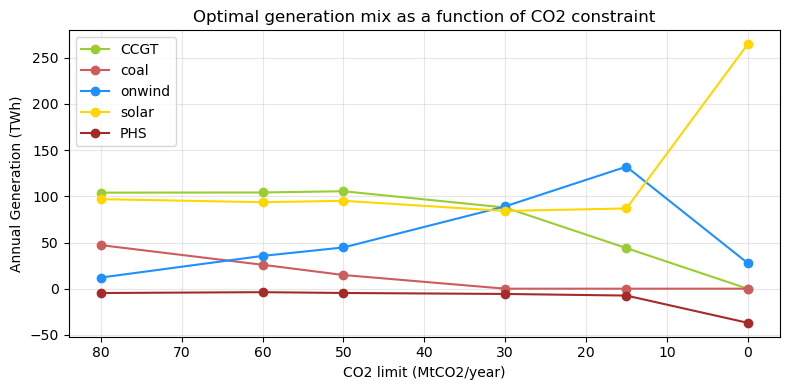

In [129]:
fig, ax = plt.subplots(figsize=(8, 4))

sensitivity_gen_df[["CCGT", "coal", "onwind", "solar", "PHS"]].plot(
    ax=ax,
    marker="o",
    color=["yellowgreen", "indianred", "dodgerblue", "gold", "brown"],
)

ax.invert_xaxis()  # x-axis goes from 80 to 0

ax.set_xlabel("CO2 limit (MtCO2/year)")
ax.set_ylabel("Annual Generation (TWh)")
ax.set_title("Optimal generation mix as a function of CO2 constraint")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [130]:
co2_price

80        6.610905
60        8.426020
50        9.058320
30       35.165871
15      261.537058
0     80915.480134
dtype: float64

(0.0, 1000.0)

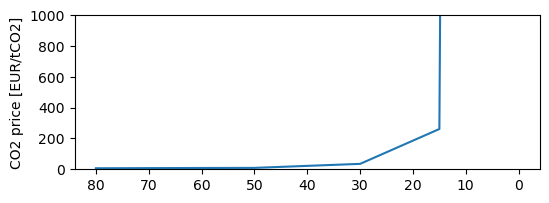

In [131]:
co2_price.plot(figsize=(6, 2), ylabel="CO2 price [EUR/tCO2]")
plt.gca().invert_xaxis()
plt.ylim([0,1000])

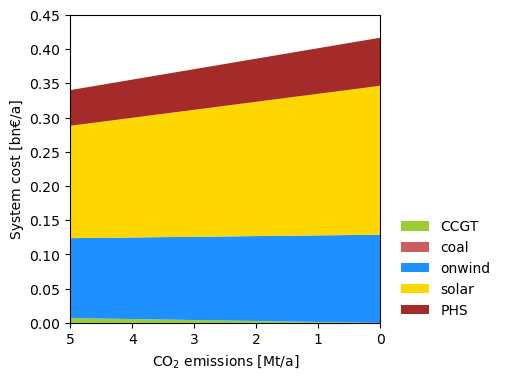

In [132]:
df = pd.DataFrame(sensitivity).T.div(1e3)  # billion Euro/a
df.plot.area(
    stacked=True,
    linewidth=0,
    color=df.columns.map(n.carriers.color),
    figsize=(4, 4),
    xlim=(0, 5),
    xlabel=r"CO$_2$ emissions [Mt/a]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 0.45),
)
plt.legend(frameon=False, loc=(1.05, 0))
plt.gca().invert_xaxis()